In [1]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(df['species_name'].value_counts())
print(df.head())

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


In [2]:
filtered = df[df['species_name'].isin(['versicolor', 'virginica'])]
filtered = filtered[['petal length (cm)', 'petal width (cm)', 'species_name']]

print(filtered.shape)
print(filtered['species_name'].value_counts())

(100, 3)
species_name
versicolor    50
virginica     50
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = filtered[['petal length (cm)', 'petal width (cm)']]
y = filtered['species_name'].map({'versicolor': 0, 'virginica': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 80
Test size: 20


In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

accuracy = knn.score(X_test, y_test)
print("KNN accuracy (k=5):", accuracy)

KNN accuracy (k=5): 0.85


In [6]:
import matplotlib.pyplot as plt

     k  Accuracy
0    1      0.90
1    2      0.85
2    3      0.85
3    4      0.85
4    5      0.85
5    6      0.85
6    7      0.85
7    8      0.85
8    9      0.85
9   10      0.85
10  11      0.85
11  12      0.85
12  13      0.85
13  14      0.85
14  15      0.85
15  16      0.90
16  17      0.90
17  18      0.90
18  19      0.90
19  20      0.90


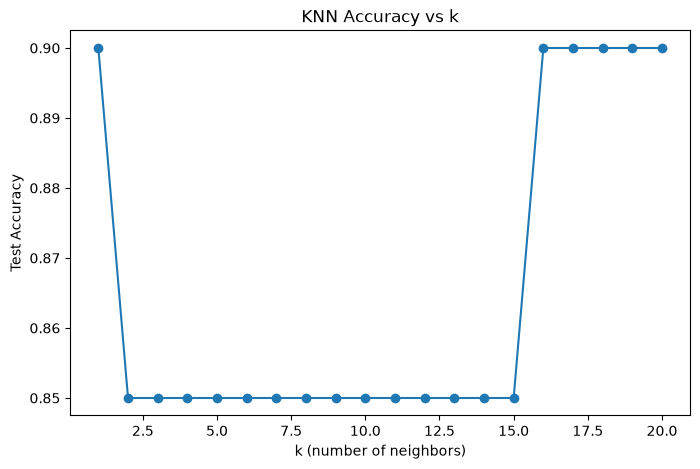

In [7]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    acc = knn_k.score(X_test, y_test)
    accuracies.append(acc)

results = pd.DataFrame({'k': k_values, 'Accuracy': accuracies})
print(results)

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Accuracy vs k')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test Accuracy')
plt.show()

In [9]:
import numpy as np

C:\Users\Abiram\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\Users\Abiram\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


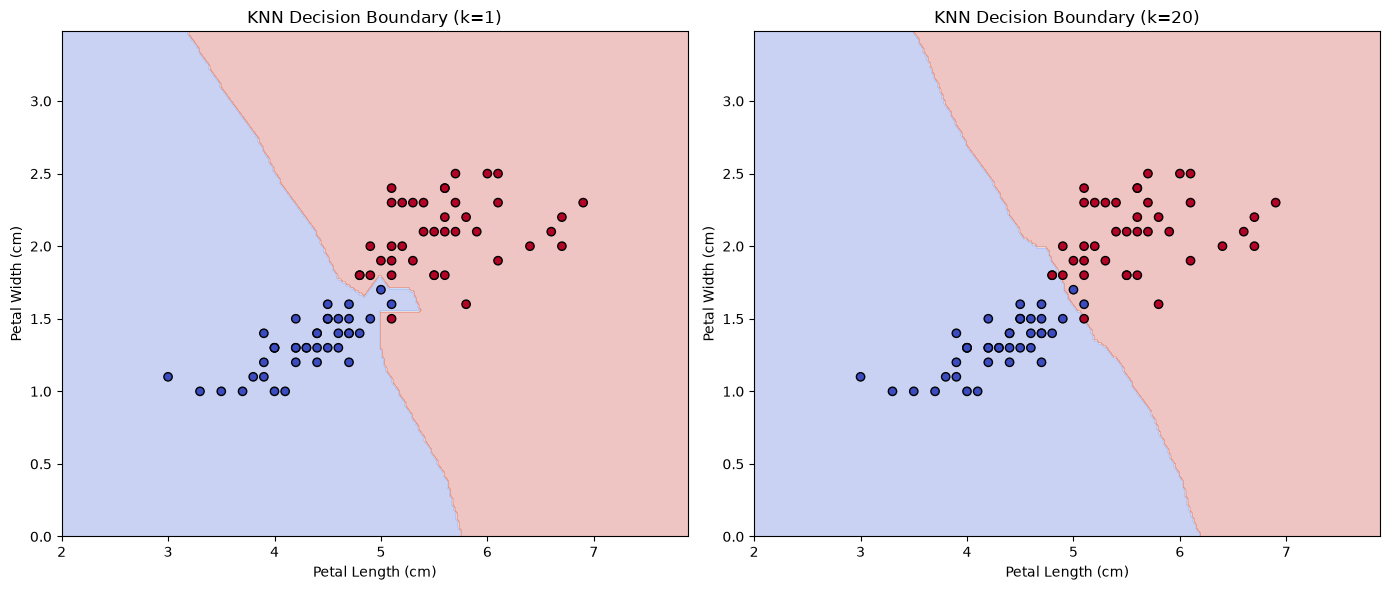

In [10]:
def plot_knn_boundary(k, X, y, ax):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X, y)
    
    x_min, x_max = X.iloc[:,0].min() - 1, X.iloc[:,0].max() + 1
    y_min, y_max = X.iloc[:,1].min() - 1, X.iloc[:,1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    Z = knn_k.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X.iloc[:,0], X.iloc[:,1], c=y, cmap='coolwarm', edgecolors='k')
    ax.set_title(f'KNN Decision Boundary (k={k})')
    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Petal Width (cm)')

fig, axes = plt.subplots(1, 2, figsize=(14,6))
plot_knn_boundary(1, X_train, y_train, axes[0])
plot_knn_boundary(20, X_train, y_train, axes[1])
plt.tight_layout()
plt.show()

With k=1, the boundary has a small irregularity because it reacts to single nearby points. With k=20, the boundary is smoother, since it's averaging over many neighbors instead of reacting to just one. Since this dataset's two groups are 
already pretty separate, the difference between the two isn't huge here

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
acc_raw = knn_raw.score(X_test, y_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = knn_scaled.score(X_test_scaled, y_test)

print("Accuracy with raw features:", acc_raw)
print("Accuracy with scaled features:", acc_scaled)

Accuracy with raw features: 0.85
Accuracy with scaled features: 0.85


Bigger k = smoother boundary, since it averages more neighbors instead of reacting to just one point. Very small k can be noisy; very large k can oversimplify. Scaling matters a lot for KNN because it uses distance - if one feature has a much bigger range, it can unfairly dominate the distance calculation. Here, scaling didn't change anything since petal length and width were already similar in scale, but it would matter more for features like Age and 
Fare in Titanic.